In [1]:
visualization_target = input("INPUT 'visualization_target RUN_ID'(e.g., run_id_0): ")

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime

from setting_for_sdm.path_setting import path_list
from setting_for_sdm.date_setting import Date_Setting


import lib.stats.stats as st
from lib.utils.file_io import *
from lib.utils.statistics import *
from lib.utils.settings import set_matplotlib
from matplotlib import pyplot as plt

import matplotlib as mpl
import lib.visualization.plot_generator as PlotGen
import lib.visualization.font_setting as font_setting
mpl.rcParams['font.family'] = font_setting.init_font()




Helvetica /home/mghan/.fonts/Helvetica/Helvetica Oblique.ttf
Registered font name: Helvetica


In [3]:
viz_dir = f'{path_list["data_root_dir"]}/result/code_complexity/{visualization_target}'
data_dir = f"{viz_dir}/data/csv"
option_dict = load_json(f"{viz_dir}/data/option.json")
output_dir = create_dir('./fig/')
date_range = 'Weekly'


std_date = Date_Setting[option_dict['year_range']]['std_date']

In [4]:
origin_df = load_df(option_dict['data_dir'], ['id', 'creationdate', 'title','tags', 'body'])
origin_df = origin_df[['id', 'creationdate']]

100%|██████████| 65/65 [00:02<00:00, 32.23it/s]


In [5]:
df = pd.read_parquet(f'{option_dict["save_dir"]}/data/all_complexity.parquet')

In [6]:
df['id'] = df['Path'].apply(lambda x : x.split('_')[1].split('.')[0])
df[['id', 'Cognitive Complexity']] = df[['id', 'Cognitive Complexity']].astype(int)

In [7]:
viz_df = pd.merge(df, origin_df, on = 'id', how='left')[['id', 'creationdate', 'Cognitive Complexity']]

In [8]:
viz_df['rel_week'] = np.floor((pd.to_datetime(viz_df['creationdate'], format='mixed')- std_date).dt.days/7)

In [9]:
# viz_df = (viz_df.groupby(['id','rel_week'], as_index=False)['Cognitive Complexity'].max()
#                 .groupby('rel_week', as_index=False)['Cognitive Complexity'].mean())

In [10]:
viz_df = (viz_df.groupby('rel_week', as_index=False)['Cognitive Complexity'].mean())

In [11]:
viz_df[viz_df['rel_week'] == 0].index.values[0]

np.int64(104)

In [12]:
plot_gen = PlotGen.PlotGen()

In [13]:
def draw_complexity_regression(ax, x, y, st_chow_1year,
                               F_stat_1, p_value_1, title,
                               panel_label=''):

    split_idx = np.where(x < 0)[0][-1] + 1

    x1 = x[:split_idx]
    x2 = x[split_idx:]

    # scatter
    ax.scatter(x, y, color='darkgray', alpha=0.7, s=10, marker='x')

    # Full model
    ax.plot(x, st_chow_1year.y_predict,
            linestyle="--", color="black",
            linewidth=1.5, label='Full model')

    # Before ChatGPT
    ax.plot(x1, st_chow_1year.y1_predict,
            linewidth=1.5, label='Before ChatGPT')

    ax.fill_between(
        x1,
        st_chow_1year.y1_predict - st_chow_1year.y1_conf_interval,
        st_chow_1year.y1_predict + st_chow_1year.y1_conf_interval,
        alpha=0.15
    )

    # After ChatGPT
    ax.plot(x2, st_chow_1year.y2_predict,
            linewidth=1.5, label='After ChatGPT')

    ax.fill_between(
        x2,
        st_chow_1year.y2_predict - st_chow_1year.y2_conf_interval,
        st_chow_1year.y2_predict + st_chow_1year.y2_conf_interval,
        alpha=0.15
    )

    # vertical line
    ax.axvline(x=0, color='#CC3333', linestyle='--', linewidth=1.2, zorder=5)

    # p-value text
    p_txt = '$p < 0.001$' if p_value_1 < 0.001 else f'$p = {p_value_1:.3f}$'
    p_color = '#CC3333' if p_value_1 < 0.05 else 'gray'

    # title
    ax.text(
        0.5, 1.08,
        f'Changes in {title} for {option_dict["selected_tags"]}',
        transform=ax.transAxes,
        fontsize=font_setting.font_setting['title'],
        ha='center',
        va='bottom'
    )

    # p-value
    ax.text(
        0.5, 1.02,
        p_txt,
        ha='center',
        fontsize=font_setting.font_setting['p-value'],
        color=p_color,
        transform=ax.transAxes
    )

    # panel label
    if panel_label:
        ax.text(
            -0.08, 1.08,
            panel_label,
            transform=ax.transAxes,
            fontsize=font_setting.font_setting['panel'],
            fontweight='bold',
            va='bottom',
            ha='left'
        )

    # axis labels
    ax.set_xlabel("Week relative to ChatGPT release", fontsize=font_setting.font_setting['label'])
    ax.set_ylabel("Weekly average complexity", fontsize=font_setting.font_setting['label'])

    # ticks
    ax.tick_params(axis='both', labelsize=font_setting.font_setting['tick'])

    # spine
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # grid
    ax.yaxis.grid(True, linestyle=':', linewidth=0.5,
                  color='gray', alpha=0.5, zorder=0)
    ax.set_axisbelow(True)

    # legend
    ax.legend(fontsize=font_setting.font_setting['legend'], frameon=False)

In [14]:

x= viz_df['rel_week'].values
y= viz_df['Cognitive Complexity'].values

st_chow_1year = st.Stats(x, y,  0.95, viz_df[viz_df['rel_week'] ==0].index.values[0])
F_stat_1, p_value_1 = st_chow_1year.chow_test()


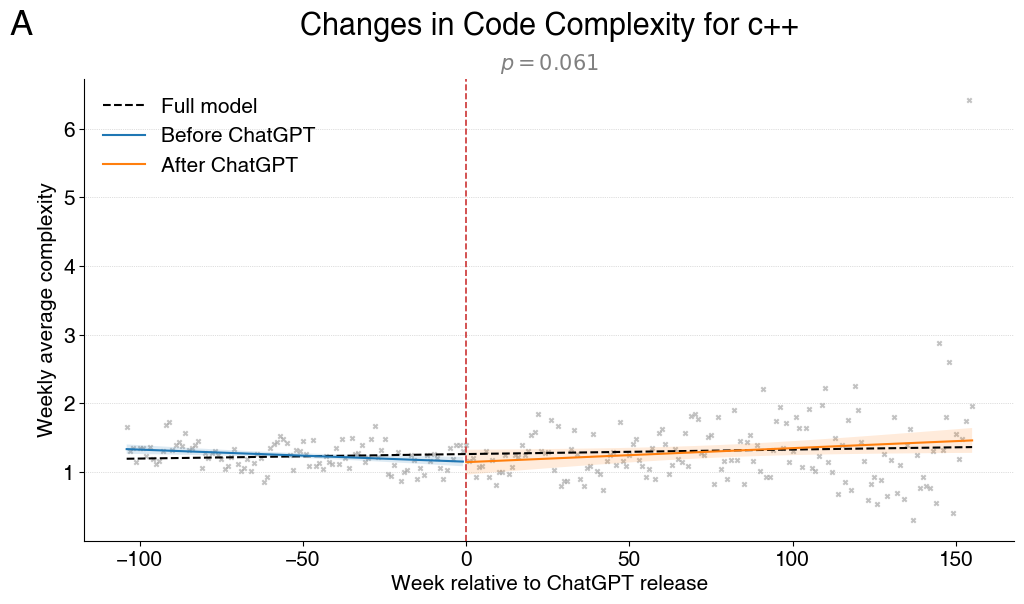

In [15]:
fig, ax = plt.subplots(figsize=(12,6))

draw_complexity_regression(
    ax,
    x,
    y,
    st_chow_1year,
    F_stat_1,
    p_value_1,
    title="Code Complexity",
    panel_label="A"
)

plt.savefig(
    f"{output_dir}/complexity_chow_ver3.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Figure 1  
ITS regression

In [ ]:
df = viz_df.copy()
df["post"] = (df["rel_week"] >= 0).astype(int)
df["time_post"] = df["rel_week"] * df["post"]

In [ ]:
import statsmodels.formula.api as smf

model_its = smf.ols(
    "Q('Cognitive Complexity') ~ rel_week + post + time_post",
    data=df
).fit(cov_type="HAC", cov_kwds={"maxlags":8})

print(model_its.summary())

In [ ]:
# 세달치로(quarterly) 데이ㅌ를 묶어서 보는걸로 수정, -8보다 작은것, 12보다 큰것은 한덩어리로 묶어서 취급
df["event_bin"] = (df["rel_week"] // 12).clip(-8, 12)


In [ ]:
df["event_bin"] = df["event_bin"].astype("category")
df["event_bin"] = df["event_bin"].cat.remove_categories([-1])

In [ ]:
import statsmodels.formula.api as smf

model_event = smf.ols(
    "Q('Cognitive Complexity') ~ C(event_bin)",
    data=df
).fit(cov_type="HAC", cov_kwds={"maxlags":8})

In [ ]:
import pandas as pd

coefs = model_event.params.filter(like="event_bin")
cis = model_event.conf_int().loc[coefs.index]

event_df = pd.DataFrame({
    "coef": coefs,
    "lower": cis[0],
    "upper": cis[1],
})

times = (
    event_df.index
    .str.extract(r"\[T\.(-?\d+\.?\d*)\]")[0]
    .astype(float)
    .astype(int)
)

event_df["time"] = times.values
event_df = event_df.sort_values("time")

In [ ]:
event_df

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

plt.errorbar(
    event_df["time"],
    event_df["coef"],
    yerr=[event_df["coef"]-event_df["lower"],
          event_df["upper"]-event_df["coef"]],
    fmt='o'
)

plt.axhline(0)
plt.axvline(0, linestyle="--")

plt.xlabel("Time relative to ChatGPT release")
plt.ylabel("Effect on cognitive complexity")

plt.show()

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(df["rel_week"], df["Cognitive Complexity"],
            color="gray", alpha=0.4)

pred = model_its.predict(df)

plt.plot(df["rel_week"], pred,
         color="black", linewidth=3,
         label="ITS regression")

event_idx = df[df["rel_week"] == 0]["rel_week"].iloc[0]

plt.axvline(event_idx,
            color="red", linestyle="--",
            label="ChatGPT release")

plt.xlabel("Week")
plt.ylabel("Complexity")
plt.legend()

plt.show()

In [ ]:
plt.figure(figsize=(9,6))

plt.scatter(
    viz_df["rel_week"],
    viz_df["Cognitive Complexity"],
    color="gray",
    alpha=0.25,
    s=25
)
plt.axvline(0, color="red", linestyle="--", label="ChatGPT")

windows = [
    (-104, 0, -52),
    (-52, 52, 0),
    (0, 104, 52),
    (52, 152, 104)
]
colors = ["blue","green","purple","orange"]

for start, end, b in windows:
    
    df_tmp = viz_df[
        (viz_df["rel_week"] >= start) &
        (viz_df["rel_week"] <= end)
    ]

    pre = df_tmp[df_tmp["rel_week"] < b]
    post = df_tmp[df_tmp["rel_week"] >= b]

    model_pre = smf.ols("Q('Cognitive Complexity') ~ rel_week", data=pre).fit()
    model_post = smf.ols("Q('Cognitive Complexity') ~ rel_week", data=post).fit()

    x_pre = np.linspace(pre.rel_week.min(), b, 50)
    x_post = np.linspace(b, post.rel_week.max(), 50)

    y_pre = model_pre.predict(pd.DataFrame({"rel_week": x_pre}))
    y_post = model_post.predict(pd.DataFrame({"rel_week": x_post}))

    plt.plot(x_pre, y_pre, linewidth=3)
    if b ==104:
        plt.plot(x_post, y_post, linewidth=3)

for _,_,b in windows:
    plt.axvline(b, color="black", linestyle=":", alpha=0.4)

plt.xlabel("Weeks relative to ChatGPT")
plt.ylabel("Cognitive Complexity")


plt.show()

In [ ]:
from scipy import stats

def chow_test(df, break_idx):

    df1 = df[df["rel_week"] < break_idx]
    df2 = df[df["rel_week"] >= break_idx]

    model_pooled = smf.ols("Q('Cognitive Complexity') ~ rel_week", data=df).fit()
    model1 = smf.ols("Q('Cognitive Complexity') ~ rel_week", data=df1).fit()
    model2 = smf.ols("Q('Cognitive Complexity') ~ rel_week", data=df2).fit()

    RSS_pooled = sum(model_pooled.resid**2)
    RSS1 = sum(model1.resid**2)
    RSS2 = sum(model2.resid**2)

    k = 2
    n1 = len(df1)
    n2 = len(df2)

    F = ((RSS_pooled - (RSS1 + RSS2)) / k) / ((RSS1 + RSS2) / (n1 + n2 - 2*k))

    p = 1 - stats.f.cdf(F, k, n1 + n2 - 2*k)

    return F, p

In [ ]:
placebo_points = placebo_points = [-78, -52, -26, 0]

results = []

for b in placebo_points:

    df_pre = viz_df[viz_df["rel_week"] < b]
    df_post = viz_df[viz_df["rel_week"] >= b]

    if len(df_pre) < 20 or len(df_post) < 20:
        continue

    F, p = chow_test(viz_df, b)

    results.append({
        "break_week": b,
        "F": F,
        "p": p
    })

placebo_df = pd.DataFrame(results)

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(placebo_df["break_week"], placebo_df["F"], marker="o")

plt.axvline(0, color="red", linestyle="--", label="ChatGPT")

plt.xlabel("Break week (relative to ChatGPT)")
plt.ylabel("Chow F-statistic")

plt.legend()
plt.show()

In [ ]:
results = []
windows = [52, 78, 104, 130]

for w in windows:

    df_tmp = viz_df[
        (viz_df["rel_week"] >= -w) &
        (viz_df["rel_week"] <= w)
    ].copy()

    df_tmp["post"] = (df_tmp["rel_week"] >= 0).astype(int)
    df_tmp["time_post"] = df_tmp["rel_week"] * df_tmp["post"]

    model = smf.ols(
        "Q('Cognitive Complexity') ~ rel_week + post + time_post",
        data=df_tmp
    ).fit(cov_type="HC3")

    results.append({
        "window": w,
        "coef_post": model.params["post"],
        "se": model.bse["post"]   # ⭐ 표준오차 저장
    })

window_df = pd.DataFrame(results)

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(window_df["window"], window_df["coef_post"], marker="o")
plt.errorbar(
    window_df["window"],
    window_df["coef_post"],
    yerr=1.96 * window_df["se"],
    marker="o",
    capsize=4
)
plt.xlabel("Window size (weeks)")
plt.ylabel("Estimated level change")

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

df["smooth"] = (
    df["Cognitive Complexity"]
    .rolling(10, center=True)
    .mean()
)

plt.plot(
    df["rel_week"],
    df["smooth"],
    linewidth=2
)

plt.axvline(
    0,
    color="red",
    linestyle="--",
    label="ChatGPT"
)

plt.xlabel("Weeks relative to ChatGPT")
plt.ylabel("Average complexity")

plt.legend()

plt.show()